# M32895 Big Data Applications - CW2
# Garbage Image Classification Using a CNN
---
**Student ID**: *UP2110919*

**Dataset**: [Garbage Classification - Kaggle](https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification)

**Main Objective**: Build, train and evaluate a Convolutional Neural Network (CNN) to classify images of waste into 12 categories, using a full ML pipeline from data collection through to individual prediction.

---

## Notebook Structure

| Step | Section |
|------|---------|
| 1 | Data Collection, Validation & Preparation |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Baseline CNN Model |
| 4 | Model Evaluation (Baseline) |
| 5 | Optimised CNN Model |
| 6 | Model Evaluation (Optimised) |
| 7 | Model Comparison & Selection |
| 8 | Prediction on Unseen Data |

---
## Step 1 - Data Collection, Validation & Preparation

### 1.1 - Import Libraries

pip install kagglehub
pip install numpy
pip install pandas matplotlib seaborn plotly tensorflow scikit-learn

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
from PIL import Image

# suppresing certain areas of the tensor flow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully.
TensorFlow version: 2.21.0


### 1.2 - Dataset Overview

The **Garbage Classification** dataset was downloaded from Kaggle. It contains **12 waste categories**:

| Label | Class |
|-------|-------|
| 0 | battery |
| 1 | biological |
| 2 | brown-glass |
| 3 | cardboard |
| 4 | clothes |
| 5 | green-glass |
| 6 | metal |
| 7 | paper |
| 8 | plastic |
| 9 | shoes |
| 10 | trash |
| 11 | white-glass |

Images are stored in sub-folders per class under `Garbage classification/Garbage classification/`. We load them using `ImageDataGenerator`.

In [2]:
# setting the data path and ensuring that all the classess (sub-folders) are identified nad then lists them

DATASET_PATH = "Garbage classification/Garbage classification"

# Confirm folder exists and list classes
if os.path.exists(DATASET_PATH):
    class_names = sorted(os.listdir(DATASET_PATH))
    class_names = [c for c in class_names if os.path.isdir(os.path.join(DATASET_PATH, c))]
    print(f'Dataset found: {DATASET_PATH}')
    print(f'Number of classes: {len(class_names)}')
    print(f'Classes: {class_names}')
else:
    print(f'ERROR: Path not found — please update DATASET_PATH')

Dataset found: Garbage classification/Garbage classification
Number of classes: 6
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### 1.3 - Data Validation

Before loading images into the model pipeline, we need validate the dataset to check for:
- The correct file formats (.jpg, .jpeg, .png only)
- Corrupt or unreadable images
- Empty class folders

In [3]:
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png') # defining the three correct extensions

def validate_dataset(root_path, class_names):
    """
    Validates each image file in the dataset.
    Checks for:
    * Valid file extension (.jpg, .jpeg, .png)
    * File can be opened without errors (not corrupt)
    Reports a summary table of valid/invalid counts per class.
    """
    summary = []
    total_valid = 0
    total_invalid = 0

    for class_name in class_names:
        class_path = os.path.join(root_path, class_name)
        valid_count = 0
        invalid_count = 0

        for filename in os.listdir(class_path):
            filepath = os.path.join(class_path, filename)

            # Check file extension
            if not filename.lower().endswith(VALID_EXTENSIONS):
                print(f'  [INVALID EXT] {class_name}/{filename}')
                invalid_count += 1
                continue

            # Try opening the image to check it is not corrupt
            try:
                img = Image.open(filepath)
                img.verify()  # Checks integrity without fully loading
                valid_count += 1
            except Exception as e:
                print(f'  [CORRUPT] {class_name}/{filename}: {e}')
                invalid_count += 1

        total_valid += valid_count
        total_invalid += invalid_count
        summary.append({'Class': class_name, 'Valid': valid_count, 'Invalid': invalid_count})

    df_summary = pd.DataFrame(summary)
    print('\n--- Validation Summary ---')
    print(df_summary.to_string(index=False))
    print(f'\nTotal valid   : {total_valid}')
    print(f'Total invalid : {total_invalid}')
    return df_summary

df_validation = validate_dataset(DATASET_PATH, class_names)


--- Validation Summary ---
    Class  Valid  Invalid
cardboard    403        0
    glass    501        0
    metal    410        0
    paper    594        0
  plastic    482        0
    trash    137        0

Total valid   : 2527
Total invalid : 0


### 1.4 - Load Images into NumPy Arrays

We load every image from thier sub-folders, resize them to 100×100 pixels, and store them as a NumPy array

We also record the integer class label for each image.

In [4]:
IMG_SIZE = (100, 100) # Specifying the X and Y pixel count

def load_images(root_path, class_names, img_size):
    """
    Loads all images from class sub-folders into NumPy arrays.
    Resizes every image to img_size (width, height).
    Returns:
    * X — NumPy array of shape (n_images, height, width, 3)
    * y — NumPy array of integer labels
    """
    X = []
    y = []

    for label_idx, class_name in enumerate(class_names):
        class_path = os.path.join(root_path, class_name)
        loaded = 0

        for filename in os.listdir(class_path):
            if not filename.lower().endswith(VALID_EXTENSIONS):
                continue
            filepath = os.path.join(class_path, filename)
            try:
                img = Image.open(filepath).convert('RGB')  # Ensure the photo has 3 colour channels
                img = img.resize(img_size)                 # Resize it to the target size
                arr = np.array(img)                        # Convert it to a NumPy array
                X.append(arr)
                y.append(label_idx)
                loaded += 1
            except Exception:
                pass  # Skip past any corrupt images

        print(f'  Loaded {loaded} images for class: {class_name}')

    X = np.array(X)  # Shape: (n_images, 100, 100, 3)
    y = np.array(y)  # Shape: (n_images,)
    return X, y

print('Loading images...')
X, y = load_images(DATASET_PATH, class_names, IMG_SIZE) # run the defined function "load_images" supplying the correct inputs

print(f'\nX shape: {X.shape}') # print the number of images, the size of each and their colour "depth".
print(f'y shape: {y.shape}') # print the number of arrays
print(f'Data type: {X.dtype}') # print the data type

Loading images...
  Loaded 403 images for class: cardboard
  Loaded 501 images for class: glass
  Loaded 410 images for class: metal
  Loaded 594 images for class: paper
  Loaded 482 images for class: plastic
  Loaded 137 images for class: trash

X shape: (2527, 100, 100, 3)
y shape: (2527,)
Data type: uint8


### 1.5 - Check a Sample Image

using a `pointer` to inspect one image from the array and confirm it looks correct before moving on

Array pointer  = 10
X[10] shape : (100, 100, 3)
Label          : 0 (cardboard)


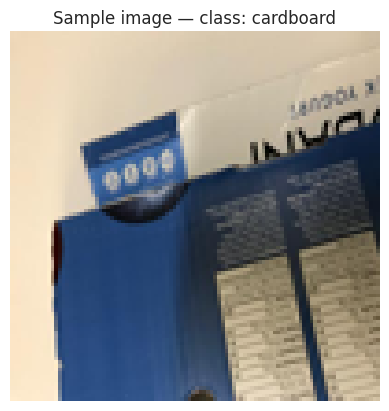

In [5]:
pointer = 10  # the index of a random image

print(f'Array pointer  = {pointer}')
print(f'X[{pointer}] shape : {X[pointer].shape}')  # Should be (100, 100, 3)
print(f'Label          : {y[pointer]} ({class_names[y[pointer]]})')

plt.imshow(X[pointer])
plt.title(f'Sample image — class: {class_names[y[pointer]]}')
plt.axis('off')
plt.show()

### 1.6 - Validate the Loaded Arrays

We validate the loaded NumPy arrays to confirm:
- Every element is a NumPy array
- Every image has the correct shape
- Pixel values are in the expected range (0–255)
- No Not a Number (NaN) values are present

In [6]:
def check_images(dataset, dataset_name):
    """
    Checks images for:
    * Being a NumPy array
    * Correct shape
    * Pixel values in range 0-255
    * No NaN values
    """
    invalid_count = 0
    valid_count = 0

    for idx, image in enumerate(dataset):
        # Check it is a NumPy array
        if not isinstance(image, np.ndarray):
            print(f'{dataset_name} - Index {idx}: Not a valid array')
            invalid_count += 1
            continue

        # Check shape is (100, 100, 3)
        if image.shape != (100, 100, 3):
            print(f'{dataset_name} - Index {idx}: Incorrect shape {image.shape}')
            invalid_count += 1
            continue

        # Check pixel values are in valid range
        if not (image.min() >= 0 and image.max() <= 255):
            print(f'{dataset_name} - Index {idx}: Invalid pixel values')
            invalid_count += 1
            continue

        # Check for NaN values
        if np.isnan(image.astype(float)).any():
            print(f'{dataset_name} - Index {idx}: Contains NaN values')
            invalid_count += 1
            continue

        valid_count += 1

    print(f'\n{dataset_name}: {valid_count} valid images, {invalid_count} invalid images')

print('Checking images...\n')
check_images(X, 'Full dataset') # running the defined function and printing valid/invlaid images

Checking images...


Full dataset: 2527 valid images, 0 invalid images


### 1.7 — Train / Validation / Test Split

We now need to split the data into **train**, **validation**, and **test** sets.

- **Train (80%)** — used to train the model
- **Validation (10%)** — used during training to monitor performance and trigger early stopping
- **Test (10%)** — kept completely unseen until final evaluation

In [7]:
# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=0)

# Second split: temp 50/50 into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=0)

print(f'* Train set      : {X_train.shape}, {y_train.shape}')
print(f'* Validation set : {X_val.shape}, {y_val.shape}')
print(f'* Test set       : {X_test.shape}, {y_test.shape}')

* Train set      : (2021, 100, 100, 3), (2021,)
* Validation set : (253, 100, 100, 3), (253,)
* Test set       : (253, 100, 100, 3), (253,)


### 1.8 - Rescale and Reshape 
Now we must:
1. Rescale pixel values from [0, 255] tp [0, 1] by dividing by 255. this normalises inputs and helps the model train faster and more stable.

| Before Scaling | After Scaling |
|----------------|---------------|
| Pixel values: 0–255 | Pixel values: 0.0–1.0 |
| Integer type (uint8) | Floating-point (float32) |
| Can cause instability in training | Helps stable and faster training |

In [8]:
# Check current max pixel value before scaling
print(f'Max pixel value before scaling: {X_train.max()}')

# Convert to float32 and rescale to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_val   = X_val.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

print(f'Max pixel value after scaling: {X_train.max()}')

Max pixel value before scaling: 255
Max pixel value after scaling: 1.0


In [ ]:
# Convert integer labels to an encoded categorical format (e.g. 0, 0, 0, 0, 1, 0)
N_LABELS = len(class_names)  # for all 6 classes

y_train = to_categorical(y_train, num_classes=N_LABELS)
y_val   = to_categorical(y_val,   num_classes=N_LABELS)
y_test  = to_categorical(y_test,  num_classes=N_LABELS)

print(f'y_train shape after encoding: {y_train.shape}')
print(f'Example encoded label: {y_train[0]}')

y_train shape after encoding: (2021, 6)
Example encoded label: [0. 0. 0. 0. 1. 0.]


---
## Step 2 - Exploratory Data Analysis (EDA)

### 2.1 - Class Distribution

### 2.2 - Sample Images Per Class

---
## Step 3 - Baseline CNN Model

---
## Step 4 - Model Evaluation (Baseline)

---
## Step 5 - Optimised CNN Model

---
## Step 6 - Model Evaluation (Optimised)

---
## Step 7 - Model Comparison and Selection

---
## Step 8 - Prediction on Unseen Data